# Experiment 1 — The Vanilla Baseline (Equal-Strength Covariates)

**Goal:** Establish the baseline failure point for the LOO benchmark under the most symmetric,
best-case setup — all observed covariates are equally informative.

**Setup**
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.5, 0.5, 0.5, 0.5, 0.5]$ — all covariates equal strength.
  This is the symmetric control: every $X_j$ contributes identically, so $B_{\max}$ is
  determined by any single leave-one-out covariate.
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps):
  $\beta_{DA} = \beta_{YA} = 0.5m$

**Benchmark:** LOO (leave-one-out) — for each observed $X_j$, treat it as the mock omitted
confounder and compute bound $B_j$.

$B_{\max} = \max_j B_j$.

**Coverage metric:** across 250 Monte Carlo trials per multiplier,
$$\text{Coverage}(m) = \Pr\bigl(|\hat{\tau}_{\text{short}} - \tau_{\text{true}}| \le B_{\max}\bigr)$$

This is the **control experiment**. Compare its cliff location to Experiment 2 (superstar
covariate) to quantify how much a single dominant predictor extends the safe zone.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
import importlib
import ovb_formula as _ovb_mod
importlib.reload(_ovb_mod)
from ovb_formula import compute_RV
from robustness_plot import plot_robustness_contour

In [2]:
tau_true   = 1.0
n_trials   = 100

# Uniform beta — every X_j has identical strength
beta_dx    = 0.5
beta_yx    = 0.5

multipliers = np.linspace(0.5, 2.0, 50)

coverage        = []
mean_ovb        = []
mean_Bmax       = []
mean_RV         = []
mean_rho        = []   # empirical tightness: |OVB| / B_max
p10_rho         = []
p90_rho         = []
mean_sig_slack  = []   # (lower 95% CI) / B_max — headroom before significance is lost
mean_r2_ax      = []   # God-mode: R²(A ~ X), how much of A escapes the observed proxies
last_trial_data = {}

for m_idx, multiplier in enumerate(multipliers):
    beta_da = 0.5 * multiplier
    beta_ya = 0.5 * multiplier

    covered        = 0
    ovb_vals       = []
    B_vals         = []
    rv_vals        = []
    rho_vals       = []
    sig_slack_vals = []
    r2_ax_vals     = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]
        se_short  = short_fit.bse[1]

        loo_results, S2_full = loo_benchmark(Y, D, X)
        B_max = max(r['B'] for r in loo_results)
        RV    = compute_RV(tau_short, S2_full)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)
        rv_vals.append(RV)

        # Empirical tightness: fraction of the LOO budget consumed by actual bias
        rho_vals.append(ovb / B_max if B_max > 0 else np.nan)

        # Significance slack: lower 95% CI relative to the LOO budget.
        # >1 → worst-case LOO bias can't kill significance; <0 → already insignificant.
        lower_ci = abs(tau_short) - 1.96 * se_short
        sig_slack_vals.append(lower_ci / B_max if B_max > 0 else np.nan)

        # God-mode: how much of A's variance does X capture?
        r2_ax_vals.append(sm.OLS(A[:, 0], sm.add_constant(X)).fit().rsquared)

        if ovb <= B_max:
            covered += 1

        last_trial_data[m_idx] = (tau_short, S2_full, loo_results)

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))
    mean_RV.append(np.mean(rv_vals))
    mean_rho.append(np.nanmean(rho_vals))
    p10_rho.append(np.nanpercentile(rho_vals, 10))
    p90_rho.append(np.nanpercentile(rho_vals, 90))
    mean_sig_slack.append(np.nanmean(sig_slack_vals))
    mean_r2_ax.append(np.nanmean(r2_ax_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}  "
          f"mean RV={mean_RV[-1]:.4f}  mean ρ={mean_rho[-1]:.3f}  "
          f"sig_slack={mean_sig_slack[-1]:.3f}  R²(A|X)={mean_r2_ax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.1027  mean B_max=0.3700  mean RV=0.4330  mean ρ=0.280  sig_slack=2.682  R²(A|X)=0.0023
m= 0.53  coverage=100.0%  mean|OVB|=0.1126  mean B_max=0.3658  mean RV=0.4371  mean ρ=0.310  sig_slack=2.742  R²(A|X)=0.0025
m= 0.56  coverage=100.0%  mean|OVB|=0.1267  mean B_max=0.3660  mean RV=0.4399  mean ρ=0.350  sig_slack=2.784  R²(A|X)=0.0025
m= 0.59  coverage=100.0%  mean|OVB|=0.1347  mean B_max=0.3649  mean RV=0.4412  mean ρ=0.373  sig_slack=2.810  R²(A|X)=0.0027
m= 0.62  coverage=100.0%  mean|OVB|=0.1433  mean B_max=0.3565  mean RV=0.4455  mean ρ=0.404  sig_slack=2.898  R²(A|X)=0.0025
m= 0.65  coverage= 99.0%  mean|OVB|=0.1778  mean B_max=0.3598  mean RV=0.4562  mean ρ=0.495  sig_slack=2.967  R²(A|X)=0.0024
m= 0.68  coverage= 99.0%  mean|OVB|=0.1954  mean B_max=0.3560  mean RV=0.4605  mean ρ=0.552  sig_slack=3.050  R²(A|X)=0.0028
m= 0.71  coverage=100.0%  mean|OVB|=0.1963  mean B_max=0.3554  mean RV=0.4609  mean ρ=0.555  sig_slack=3.059  R²(A|X)=0.0024


In [3]:
np.save('experiment_01_results.npy', {
    'multipliers':    np.array(multipliers),
    'coverage':       np.array(coverage),
    'mean_ovb':       np.array(mean_ovb),
    'mean_Bmax':      np.array(mean_Bmax),
    'mean_RV':        np.array(mean_RV),
    'mean_rho':       np.array(mean_rho),
    'p10_rho':        np.array(p10_rho),
    'p90_rho':        np.array(p90_rho),
    'mean_sig_slack': np.array(mean_sig_slack),
    'mean_r2_ax':     np.array(mean_r2_ax),
}, allow_pickle=True)
print("Saved → experiment_01_results.npy")

Saved → experiment_01_results.npy


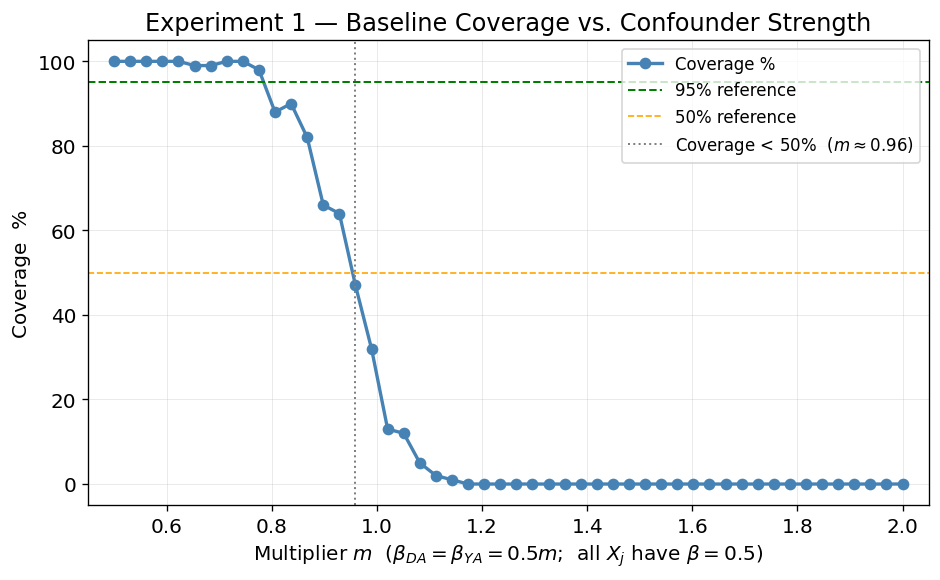

In [4]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$;  all $X_j$ have $\beta=0.5$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 1 — Baseline Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_coverage.png', bbox_inches='tight')
plt.show()

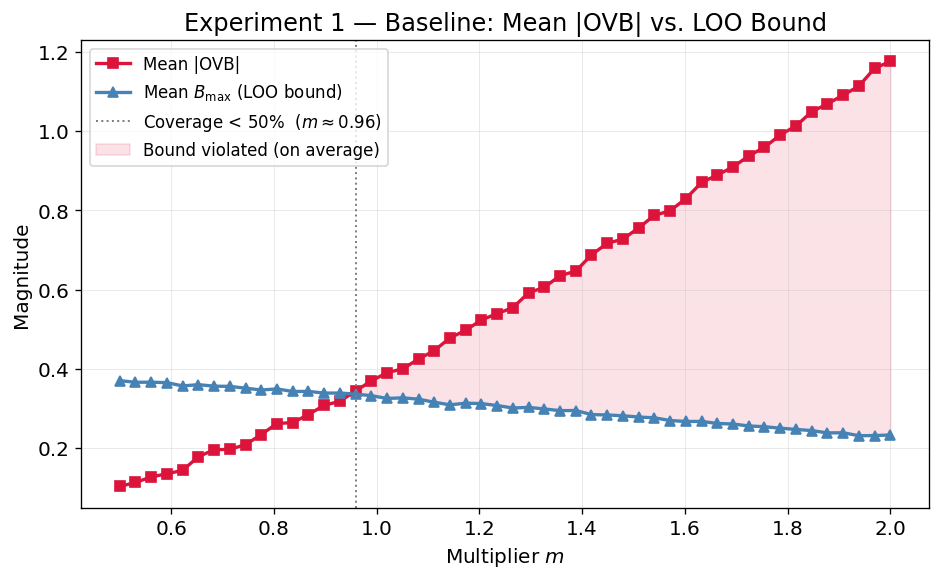

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 1 — Baseline: Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

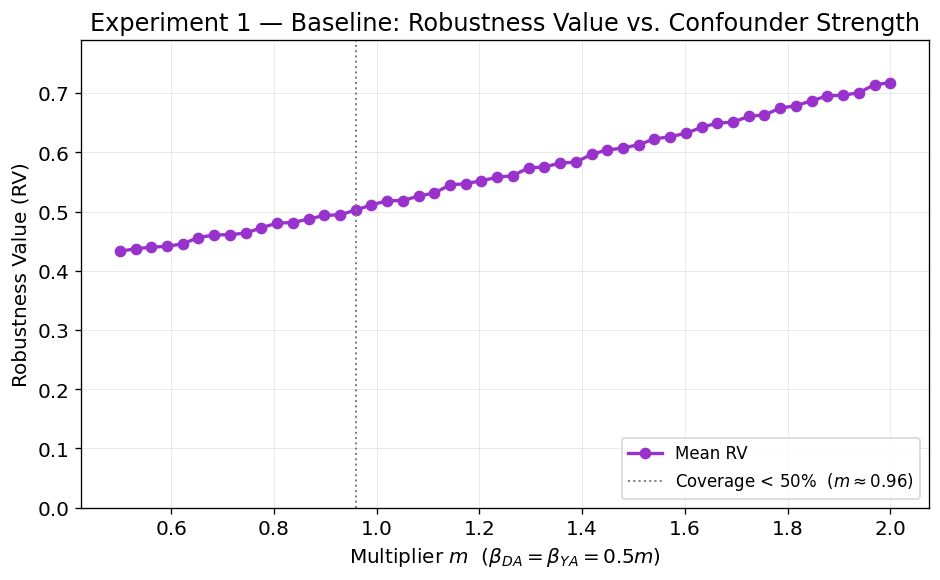

In [6]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_RV, marker='o', linewidth=2, color='darkorchid', label='Mean RV')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$)')
ax.set_ylabel('Robustness Value (RV)')
ax.set_title('Experiment 1 — Baseline: Robustness Value vs. Confounder Strength')
ax.set_ylim(0, max(mean_RV) * 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_rv.png', bbox_inches='tight')
plt.show()

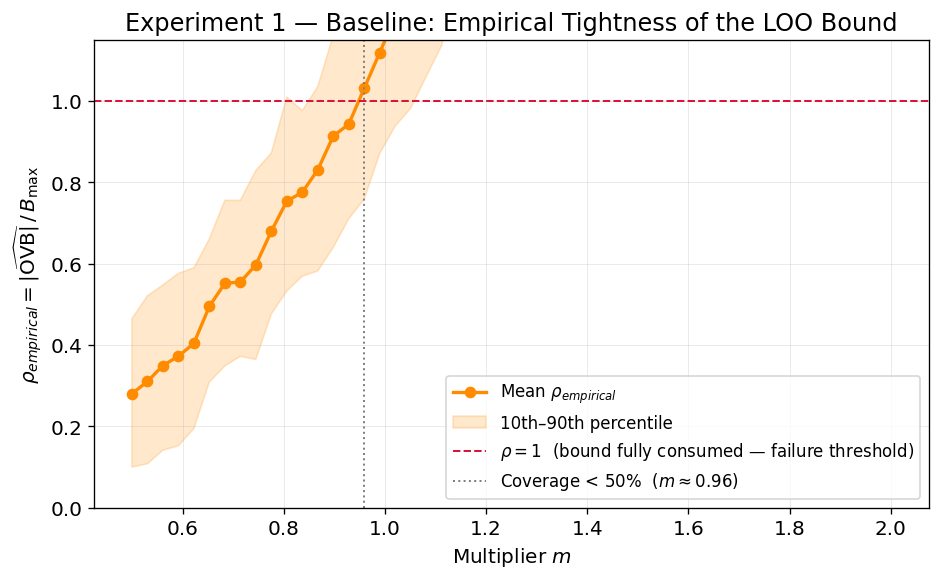

In [7]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_rho, marker='o', linewidth=2, color='darkorange',
        label=r'Mean $\rho_{empirical}$')
ax.fill_between(multipliers, p10_rho, p90_rho,
                alpha=0.2, color='darkorange', label='10th–90th percentile')
ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = 1$  (bound fully consumed — failure threshold)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$\rho_{empirical} = |\widehat{\mathrm{OVB}}| \,/\, B_{\max}$')
ax.set_title('Experiment 1 — Baseline: Empirical Tightness of the LOO Bound')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_rho.png', bbox_inches='tight')
plt.show()

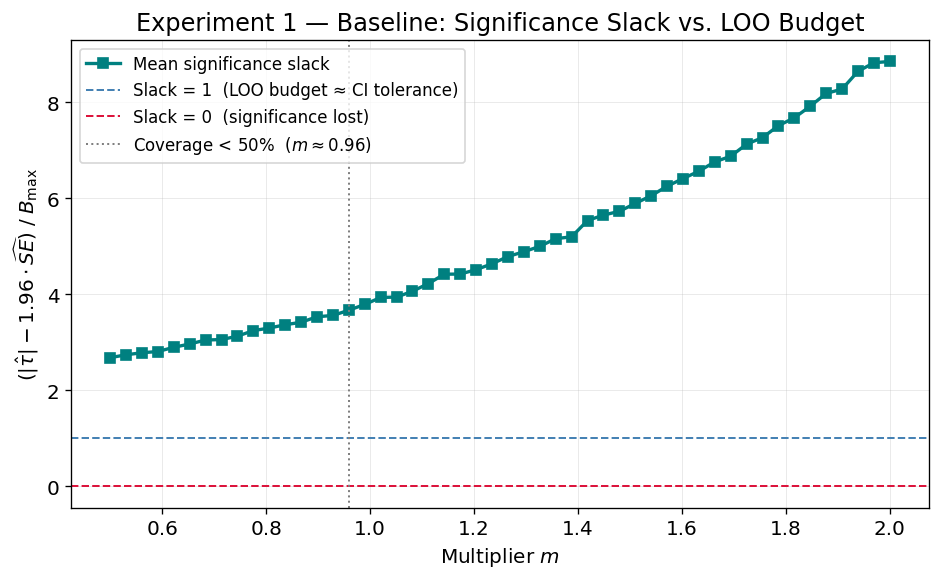

In [8]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_sig_slack, marker='s', linewidth=2, color='teal',
        label='Mean significance slack')
ax.axhline(1.0, linestyle='--', color='steelblue', linewidth=1.2,
           label='Slack = 1  (LOO budget ≈ CI tolerance)')
ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1.2,
           label='Slack = 0  (significance lost)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96 \cdot \widehat{SE}) \;/\; B_{\max}$')
ax.set_title('Experiment 1 — Baseline: Significance Slack vs. LOO Budget')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_sig_slack.png', bbox_inches='tight')
plt.show()

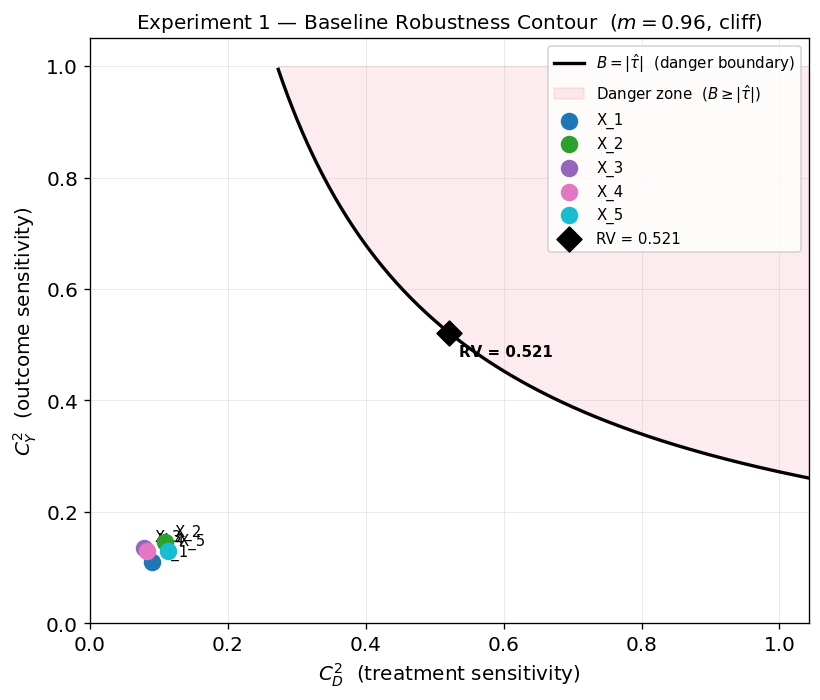

In [9]:
# Robustness contour at the cliff multiplier (first m where coverage < 50%)
cliff_idx  = next((i for i, c in enumerate(coverage) if c < 50), len(multipliers) - 1)
cliff_m    = multipliers[cliff_idx]
tau_s, S2, loo_r = last_trial_data[cliff_idx]

fig, ax = plt.subplots(figsize=(7, 6))
plot_robustness_contour(
    tau_hat     = tau_s,
    S2          = S2,
    loo_results = loo_r,
    ax          = ax,
    title       = f'Experiment 1 — Baseline Robustness Contour  ($m = {cliff_m:.2f}$, cliff)',
)
plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_contour.png', bbox_inches='tight')
plt.show()

In [14]:
import pandas as pd

df = pd.DataFrame({
    'Multiplier':   multipliers,
    'beta_DA':      0.5 * multipliers,
    'Coverage (%)': coverage,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
    'Mean ρ':       mean_rho,
    'Sig Slack':    mean_sig_slack,
    'R²(A|X)':      mean_r2_ax,
})

df = df.round(4)
df.style.format(precision=4) \
        .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100) \
        .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1) \
        .background_gradient(subset=['Mean ρ'],       cmap='RdYlGn_r', vmin=0, vmax=1) \
        .background_gradient(subset=['Sig Slack'],    cmap='RdYlGn', vmin=-1, vmax=2)

,Multiplier,beta_DA,Coverage (%),Mean |OVB|,Mean B_max,Bound Slack,Mean ρ,Sig Slack,R²(A|X)
0,0.5000,0.2500,100.0000,0.1027,0.3700,0.2672,0.2802,2.6816,0.0023
1,0.5306,0.2653,100.0000,0.1126,0.3658,0.2532,0.3104,2.7421,0.0025
2,0.5612,0.2806,100.0000,0.1267,0.3660,0.2393,0.3495,2.7841,0.0025
3,0.5918,0.2959,100.0000,0.1347,0.3649,0.2302,0.3726,2.8099,0.0027
4,0.6224,0.3112,100.0000,0.1433,0.3565,0.2132,0.4042,2.8981,0.0025
5,0.6531,0.3265,99.0000,0.1778,0.3598,0.1820,0.4952,2.9669,0.0024
6,0.6837,0.3418,99.0000,0.1954,0.3560,0.1605,0.5520,3.0496,0.0028
7,0.7143,0.3571,100.0000,0.1963,0.3554,0.1591,0.5552,3.0588,0.0024
8,0.7449,0.3724,100.0000,0.2082,0.3508,0.1426,0.5971,3.1297,0.0026
9,0.7755,0.3878,98.0000,0.2338,0.3463,0.1124,0.6800,3.2461,0.0024


## Interpretation

- **$m < $ cliff (safe zone):** All $X_j$ covariates are equally strong, so $B_{\max}$ is
  identical across all leave-one-out benchmarks.  As long as $A$ is weaker than any $X_j$,
  coverage holds.

- **At the cliff:** Because there is no superstar covariate to act as an anchor, the cliff is
  **sharper** than in Experiment 2.  Once $A$'s partial $R^2$ exceeds the uniform $X_j$ level,
  all five benchmarks fail simultaneously and coverage drops steeply.

- **Past the cliff:** Coverage collapses to 0%.  $B_{\max}$ shrinks as the uniform $X_j$'s
  become relatively less informative compared to $A$.

**Compare to Experiment 2 (superstar):** The cliff here occurs at a lower multiplier $m$
because no single $X_j$ has a large enough partial $R^2$ to keep $B_{\max}$ competitive.
The gap between these two cliff locations quantifies how much a single dominant covariate
extends the LOO bound's protective range.

**What $m$ actually means:** $m$ scales the hidden confounder's coefficient relative to the
observed covariates.  At $m = 1$, $A$ has the same raw coefficient ($0.5$) as each $X_j$.
The bound fails *before* $m = 1$ because partial $R^2$ comparisons are stricter than
raw coefficient comparisons — $A$ competes against the collective explanatory power of all
five $X_j$'s, not just one.

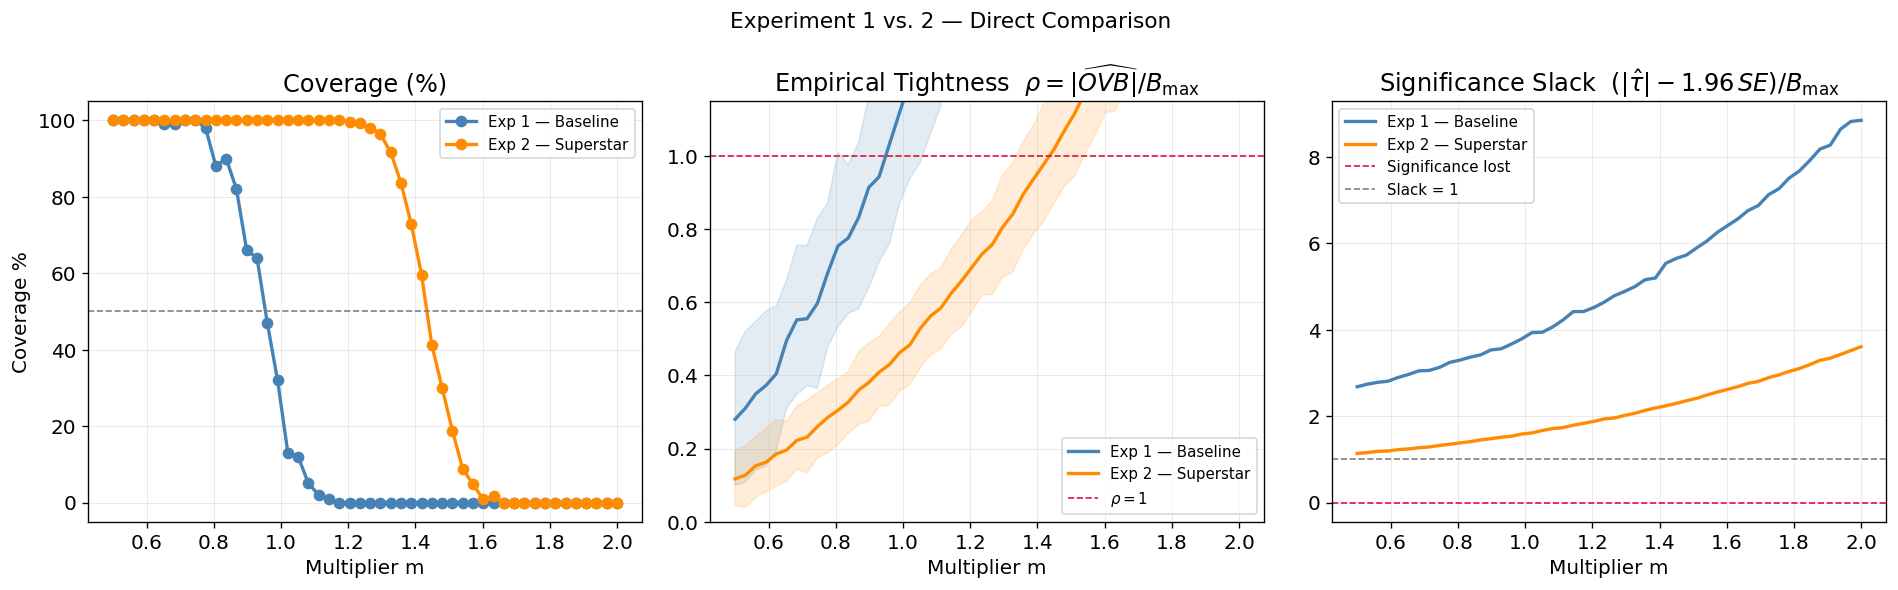

In [12]:
try:
    r1 = np.load('experiment_01_results.npy', allow_pickle=True).item()
    r2 = np.load('experiment_02_results.npy', allow_pickle=True).item()
except FileNotFoundError as e:
    print(f"Missing: {e} — run both experiment notebooks first.")
    r1 = r2 = None

if r1 is not None and r2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Coverage
    ax = axes[0]
    ax.plot(r1['multipliers'], r1['coverage'], marker='o', linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.plot(r2['multipliers'], r2['coverage'], marker='o', linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.axhline(50, linestyle='--', color='gray', linewidth=1)
    ax.set_title('Coverage (%)')
    ax.set_xlabel('Multiplier m')
    ax.set_ylabel('Coverage %')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Empirical tightness with fan
    ax = axes[1]
    ax.plot(r1['multipliers'], r1['mean_rho'], linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.fill_between(r1['multipliers'], r1['p10_rho'], r1['p90_rho'],
                    alpha=0.15, color='steelblue')
    ax.plot(r2['multipliers'], r2['mean_rho'], linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.fill_between(r2['multipliers'], r2['p10_rho'], r2['p90_rho'],
                    alpha=0.15, color='darkorange')
    ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1, label=r'$\rho = 1$')
    ax.set_title(r'Empirical Tightness  $\rho = |\widehat{OVB}| / B_{\max}$')
    ax.set_xlabel('Multiplier m')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Significance slack
    ax = axes[2]
    ax.plot(r1['multipliers'], r1['mean_sig_slack'], linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.plot(r2['multipliers'], r2['mean_sig_slack'], linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1, label='Significance lost')
    ax.axhline(1.0, linestyle='--', color='gray', linewidth=1, label='Slack = 1')
    ax.set_title(r'Significance Slack  $(|\hat{\tau}| - 1.96\,SE) / B_{\max}$')
    ax.set_xlabel('Multiplier m')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Experiment 1 vs. 2 — Direct Comparison', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/experiment_comparison.png', bbox_inches='tight')
    plt.show()